# New SDSSRM-XCS Relations: Collating scatter dominating cluster names

This notebook uses the scatter-dominating galaxy cluster results from the jackknifing analysis of new SDSSRM-XCS scaling relations to produce tables and visualisations summarising which clusters were removed for each relation.

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM
from astropy.visualization import ImageNormalize, LogStretch, MinMaxInterval, AsinhStretch, SqrtStretch
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import xcs_cosmo, tx_norm, m_norm

# Setting up this constant that controls the confidence intervals calculated for the scatter change
#  distributions - makes it much easier to change the exact value later if we need too. This is 
#  what is going to be used to define the scatter-dominating clusters.
CONF_PERC = 90

## Output paths

Paths to save figures and output files - defined here to avoid repetition and make the code easier to read:

In [2]:
rel_fig_path = "../../outputs/figures/misc/"
os.makedirs(rel_fig_path, exist_ok=True)

## Useful values 

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [3]:
LATEX_REL_NAMES = {'mtot500_tx500': r'$M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$',
                   'mtot500_tx500ce': r'$M^{\rm{tot}}_{500}$-$T_{\rm{X,500ce}}$',
                   'mtot2500_tx2500': r'$M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$',
                   
                   'mtot500_lx52_500': r'$M^{\rm{tot}}_{500}$-$L^{0.5-2.0}_{\rm{X,500}}$',
                   'mtot500_lx52_500ce': r'$M^{\rm{tot}}_{500}$-$L^{0.5-2.0}_{\rm{X,500ce}}$',
                   'mtot2500_lx52_2500': r'$M^{\rm{tot}}_{2500}$-$L^{0.5-2.0}_{\rm{X,2500}}$',
                   
                   'mtot500_lxbol_500': r'$M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500}}$',
                   'mtot500_lxbol_500ce': r'$M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$',
                   'mtot2500_lxbol_2500': r'$M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$',

                   'mtot500_richness': r'$M^{\rm{tot}}_{500}$-$\lambda_{\rm{RM}}$',
                   'mtot2500_richness': r'$M^{\rm{tot}}_{2500}$-$\lambda_{\rm{RM}}$',
                   
                   'mtot500_mgas500': r'$M^{\rm{tot}}_{500}$-$M^{\rm{gas}}_{500}$',
                   'mtot2500_mgas2500': r'$M^{\rm{tot}}_{2500}$-$M^{\rm{gas}}_{2500}$',

                   'mgas500_richness': r'$M^{\rm{gas}}_{500}$-$\lambda_{\rm{RM}}$',
                   'mgas2500_richness': r'$M^{\rm{gas}}_{2500}$-$\lambda_{\rm{RM}}$',
                   
                   'mgas500_tx500': r'$M^{\rm{gas}}_{500}$-$T_{\rm{X,500}}$',
                   'mgas500_tx500ce': r'$M^{\rm{gas}}_{500}$-$T_{\rm{X,500ce}}$',
                   'mgas2500_tx2500': r'$M^{\rm{gas}}_{2500}$-$T_{\rm{X,2500}}$',
                   
                   'mgas500_lx52_500': r'$M^{\rm{gas}}_{500}$-$L^{0.5-2.0}_{\rm{X,500}}$',
                   'mgas500_lx52_500ce': r'$M^{\rm{gas}}_{500}$-$L^{0.5-2.0}_{\rm{X,500ce}}$',
                   'mgas2500_lx52_2500': r'$M^{\rm{gas}}_{2500}$-$L^{0.5-2.0}_{\rm{X,2500}}$',
                   'mgas500_lxbol_500': r'$M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500}}$',
                   'mgas500_lxbol_500ce': r'$M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$',
                   'mgas2500_lxbol_2500': r'$M^{\rm{gas}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$'
                   }

## Loading data files

Important considerations for this dataset:
* The

### SDSSRM-XCS base sample

In [4]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


### SDSSRM-XCS scatter dominating clusters

Rather than being in one large file, the information used to define 'scatter-dominating' clusters is housed individually for each scaling relation - as such we have to loop through those files to read in all the data we need for this notebook. 

#### Setting up path to result files

In [5]:
sc_dom_res_path = "../../outputs/result_files/exploring_scatter/leave_one_jackknife/"

#### Fetching the names of 'scatter-dominating' clusters from jackknifing result files

In [6]:
# Setting up a storage dictionary for the names of scatter-dominating clusters
sc_dom_names = {}
sc_dom_tables = {}

# Iterating through all the relations
for rel_type in [n for n in os.listdir(sc_dom_res_path) if n[0] != '.']:
    cur_rel_path = os.path.join(sc_dom_res_path, rel_type)
    rel_sc_dom_files = [f for f in os.listdir(cur_rel_path) if f[0] != '.']

    for cur_sc_dom_file in rel_sc_dom_files:
        # The full file path
        cur_sc_dom_file_path = os.path.join(cur_rel_path, cur_sc_dom_file)
        # Splitting out the relation name
        cur_rel_name = cur_sc_dom_file_path.split('/')[-1].split('_l1')[0]
        # Reading the CSV
        rel_data = pd.read_csv(cur_sc_dom_file_path)
        
        # At one point I made a mistake and was saving these result files with a useless 
        #  extra column, so we check for them, remove, and re-save the file here
        if 'Unnamed: 0' in rel_data.columns:
            rel_data = rel_data.drop(columns='Unnamed: 0')
            rel_data.to_csv(cur_sc_dom_file_path, index=False)
            
        # We currently re-run the quick check that defines scatter dominating clusters 
        # TODO REMOVE THIS WHEN A SCATTER DOMINATING CLASSIFICATION COLUMN IS INCLUDED IN THE SAVE FILES
        cur_low = np.percentile(rel_data['scatter_perc_change'].values, (50-(CONF_PERC/2)))
        # The dataframe for the scatter dominating clusters
        cur_domin = rel_data[rel_data['scatter_perc_change'] < cur_low]

        # Add the names to the storage dictionary - I don't anticipate that there will be duplicate
        #  scaling relation names in the files, but will check anyway
        if cur_rel_name in sc_dom_names:
            raise KeyError("{n} already has an entry in 'sc_dom_names'".format(n=cur_rel_name))
        
        # Store the names
        sc_dom_names[cur_rel_name] = cur_domin['dropped_cluster'].values
        # We also store the full tables
        sc_dom_tables[cur_rel_name] = cur_domin

Padding so that all lists of names are the same length (this will help with Pandas later):

In [7]:
num_most_names = max([len(sdn) for sdn in sc_dom_names.values()])
for rel_name, cur_sdn in sc_dom_names.items():

    if len(cur_sdn) != num_most_names:
        diff = num_most_names - len(cur_sdn)
        cur_sdn = np.append(cur_sdn, np.array(['']*diff))
        sc_dom_names[rel_name] = cur_sdn

## Creating a table of scatter dominating cluster names

We can now tabulate the names of clusters that we have defined as 'scatter-dominating':

### Setting up a dataframe

We can simply feed the dictionary we constructed in the previous section into a Pandas DataFrame - then we ensure that the order of the rows is consistent with the order of the MOR relation table in the paper:

In [8]:
scatt_dom_clusters = pd.DataFrame.from_dict(sc_dom_names).T
# I now order the dataframe by the LATEX_REL_NAMES dictionary labels, as they are in the 
#  same order as the tables in the paper
scatt_dom_clusters = scatt_dom_clusters.loc[np.array(list(LATEX_REL_NAMES.keys()))]
scatt_dom_clusters

,0,1,2,3,4,5
mtot500_tx500,SDSSXCS-15,SDSSXCS-22,SDSSXCS-382,SDSSXCS-5,SDSSXCS-6955,SDSSXCS-8060
mtot500_tx500ce,SDSSXCS-15,SDSSXCS-22,SDSSXCS-382,SDSSXCS-480,SDSSXCS-6955,SDSSXCS-8060
mtot2500_tx2500,SDSSXCS-176,SDSSXCS-2836,SDSSXCS-34,SDSSXCS-457,SDSSXCS-8060,
mtot500_lx52_500,SDSSXCS-11331,SDSSXCS-155,SDSSXCS-22,SDSSXCS-2282,SDSSXCS-6955,SDSSXCS-8060
mtot500_lx52_500ce,SDSSXCS-10401,SDSSXCS-22,SDSSXCS-2282,SDSSXCS-5159,SDSSXCS-6955,SDSSXCS-8060
mtot2500_lx52_2500,SDSSXCS-10401,SDSSXCS-11331,SDSSXCS-5225,SDSSXCS-8060,SDSSXCS-9803,
mtot500_lxbol_500,SDSSXCS-155,SDSSXCS-22,SDSSXCS-2282,SDSSXCS-5159,SDSSXCS-6955,SDSSXCS-8060
mtot500_lxbol_500ce,SDSSXCS-22,SDSSXCS-2282,SDSSXCS-382,SDSSXCS-5159,SDSSXCS-6955,SDSSXCS-8060
mtot2500_lxbol_2500,SDSSXCS-10401,SDSSXCS-11331,SDSSXCS-176,SDSSXCS-5225,SDSSXCS-8060,
mtot500_richness,SDSSXCS-210,SDSSXCS-22,SDSSXCS-2282,SDSSXCS-586,SDSSXCS-6955,SDSSXCS-8060


### Generating a LaTeX table

Our table doesn't need to have one column per scatter-dominating cluster name, so we modify the dataframe and join the names into a single string - this is both more space-efficient and should be easier to read:

In [9]:
mod_scatt_dom_clusters = scatt_dom_clusters.copy()
mod_scatt_dom_clusters['Scatter Dominating Clusters'] = mod_scatt_dom_clusters.apply(lambda x: 'SDSSXCS-'+", ".join(x.str.replace('SDSSXCS-', '')), axis=1)
mod_scatt_dom_clusters = mod_scatt_dom_clusters['Scatter Dominating Clusters'].reset_index().rename(columns={'index': 'Relation'})
mod_scatt_dom_clusters

,Relation,Scatter Dominating Clusters
0,mtot500_tx500,"SDSSXCS-15, 22, 382, 5, 6955, 8060"
1,mtot500_tx500ce,"SDSSXCS-15, 22, 382, 480, 6955, 8060"
2,mtot2500_tx2500,"SDSSXCS-176, 2836, 34, 457, 8060,"
3,mtot500_lx52_500,"SDSSXCS-11331, 155, 22, 2282, 6955, 8060"
4,mtot500_lx52_500ce,"SDSSXCS-10401, 22, 2282, 5159, 6955, 8060"
5,mtot2500_lx52_2500,"SDSSXCS-10401, 11331, 5225, 8060, 9803,"
6,mtot500_lxbol_500,"SDSSXCS-155, 22, 2282, 5159, 6955, 8060"
7,mtot500_lxbol_500ce,"SDSSXCS-22, 2282, 382, 5159, 6955, 8060"
8,mtot2500_lxbol_2500,"SDSSXCS-10401, 11331, 176, 5225, 8060,"
9,mtot500_richness,"SDSSXCS-210, 22, 2282, 586, 6955, 8060"


We can use Pandas' handy LaTeX conversion function to make an initial table:

In [10]:
init_lat_tab = mod_scatt_dom_clusters.to_latex(index=False)
print(init_lat_tab)

\begin{tabular}{ll}
\toprule
Relation & Scatter Dominating Clusters \\
\midrule
mtot500_tx500 & SDSSXCS-15, 22, 382, 5, 6955, 8060 \\
mtot500_tx500ce & SDSSXCS-15, 22, 382, 480, 6955, 8060 \\
mtot2500_tx2500 & SDSSXCS-176, 2836, 34, 457, 8060,  \\
mtot500_lx52_500 & SDSSXCS-11331, 155, 22, 2282, 6955, 8060 \\
mtot500_lx52_500ce & SDSSXCS-10401, 22, 2282, 5159, 6955, 8060 \\
mtot2500_lx52_2500 & SDSSXCS-10401, 11331, 5225, 8060, 9803,  \\
mtot500_lxbol_500 & SDSSXCS-155, 22, 2282, 5159, 6955, 8060 \\
mtot500_lxbol_500ce & SDSSXCS-22, 2282, 382, 5159, 6955, 8060 \\
mtot2500_lxbol_2500 & SDSSXCS-10401, 11331, 176, 5225, 8060,  \\
mtot500_richness & SDSSXCS-210, 22, 2282, 586, 6955, 8060 \\
mtot2500_richness & SDSSXCS-10401, 15, 212, 32, 7416,  \\
mtot500_mgas500 & SDSSXCS-10401, 22, 2282, 5159, 6955, 8060 \\
mtot2500_mgas2500 & SDSSXCS-176, 457, 5159, 5225, 8060,  \\
mgas500_richness & SDSSXCS-210, 22, 2282, 586, 6955, 8060 \\
mgas2500_richness & SDSSXCS-15, 15984, 165, 176, 32,  \\
mgas5

Now we can improve the LaTeX table:

In [11]:
lat_tab = "\\begin{table}\n\\begin{center}\n" + init_lat_tab + "\\end{center}\n\\end{table}\n"
for rel_name, lat_name in LATEX_REL_NAMES.items():
    # Makes the relation names LaTeX math so they look pretty
    lat_tab = lat_tab.replace(rel_name, lat_name)
    # Replaces toprule, midrule, and bottomrule
    lat_tab = lat_tab.replace("\\toprule", "\\hline\n\\hline")
    lat_tab = lat_tab.replace("\\midrule", "\\hline\n\\hline")
    lat_tab = lat_tab.replace("\\bottomrule", "\\hline")
    # Put comment lines in to increase the readability of the LaTeX code
    lat_tab = str(lat_tab).replace('\\\\\n', '\\\\[1mm] \n % \n')
    # Fixing a problem introduced by the last modification
    lat_tab = lat_tab.replace(r'Clusters \\[1mm]', r'Clusters \\')
    # Removing trailing commas where the appear
    lat_tab = lat_tab.replace(",  ", ' ')
    
print(lat_tab)

\begin{table}
\begin{center}
\begin{tabular}{ll}
\hline
\hline
Relation & Scatter Dominating Clusters \\ 
 % 
\hline
\hline
$M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$ & SDSSXCS-15, 22, 382, 5, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$ce & SDSSXCS-15, 22, 382, 480, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$ & SDSSXCS-176, 2836, 34, 457, 8060 \\m] 
 % 
$M^{\rm{tot}}_{500}$-$L^{0.5-2.0}_{\rm{X,500}}$ & SDSSXCS-11331, 155, 22, 2282, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{500}$-$L^{0.5-2.0}_{\rm{X,500}}$ce & SDSSXCS-10401, 22, 2282, 5159, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{2500}$-$L^{0.5-2.0}_{\rm{X,2500}}$ & SDSSXCS-10401, 11331, 5225, 8060, 9803 \\m] 
 % 
$M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500}}$ & SDSSXCS-155, 22, 2282, 5159, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500}}$ce & SDSSXCS-22, 2282, 382, 5159, 6955, 8060 \\m] 
 % 
$M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$ & SDSSXCS-10401, 11331, 176, 5225, 8060 \\m] 
 % 
$M^{\r

### Which clusters are classed as 'scatter-dominating' for at least one relation? 

Here we find the unique values present in the dataframe shown above:

In [12]:
sc_dom_for_any = pd.unique(scatt_dom_clusters.values.flatten())
# Drop the null value we inserted to pad arrays earlier
sc_dom_for_any = sc_dom_for_any[sc_dom_for_any != '']
# Sort them on their RM ID
sc_dom_for_any = sc_dom_for_any[np.argsort([int(n.split('-')[-1]) for n in sc_dom_for_any])]
sc_dom_for_any

array(['SDSSXCS-5', 'SDSSXCS-15', 'SDSSXCS-22', 'SDSSXCS-32',
       'SDSSXCS-34', 'SDSSXCS-155', 'SDSSXCS-165', 'SDSSXCS-176',
       'SDSSXCS-210', 'SDSSXCS-212', 'SDSSXCS-382', 'SDSSXCS-457',
       'SDSSXCS-480', 'SDSSXCS-586', 'SDSSXCS-1628', 'SDSSXCS-2282',
       'SDSSXCS-2288', 'SDSSXCS-2836', 'SDSSXCS-3312', 'SDSSXCS-5020',
       'SDSSXCS-5159', 'SDSSXCS-5225', 'SDSSXCS-6955', 'SDSSXCS-7416',
       'SDSSXCS-8060', 'SDSSXCS-9803', 'SDSSXCS-10401', 'SDSSXCS-11331',
       'SDSSXCS-15984'], dtype=object)

How many are there?

In [13]:
len(sc_dom_for_any)

29

## Visually representing the scatter dominating clusters of each relation

In [14]:
# This array will have values inserted into it that indicate whether a particular cluster was 'scatter dominating'
#  for a particular relation - the first array axis represents relations, and the second the clusters. 
# The values will represent the percentage scatter change
sc_ch_arr = np.full((len(scatt_dom_clusters), len(sc_dom_for_any)), np.nan)

# Lazy for looping but oh well - also not the most elegant way I could have written this
for name_ind, name in enumerate(sc_dom_for_any):
    for rel_name_ind, rel_name in enumerate(sc_dom_names):
        rel_cluster_names = sc_dom_names[rel_name]
        if name not in rel_cluster_names:
            continue

        # Fetch the table containing scatter percentage change values for the current relation
        rel_table = sc_dom_tables[rel_name]
        rel_row = rel_table[rel_table['dropped_cluster'] == name].iloc[0]
        sc_ch_arr[rel_name_ind, name_ind] = rel_row['scatter_perc_change']

### Scatter dominating cluster grid

The first visualization will only whether or not a particular cluster is 'scatter dominating' for a particular relation:

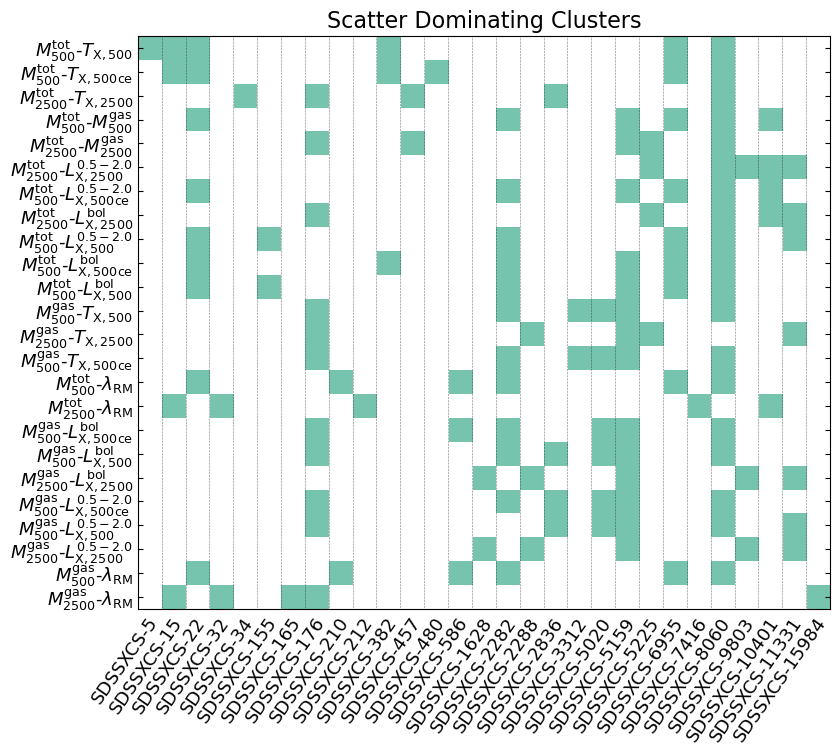

In [15]:
plt.figure(figsize=(8.5, 7.5))
ax = plt.gca()

plt.tick_params(which='both', direction='in', top=False, right=True, bottom=False, left=True, labeltop=False)

# Make a special binary version of the scatter change array
bin_sc_dom_arr = sc_ch_arr.copy()
bin_sc_dom_arr[(bin_sc_dom_arr != 0) & (~np.isnan(bin_sc_dom_arr))] = 1
plt.imshow(bin_sc_dom_arr, cmap='Dark2', alpha=0.6)

x_tick_vals = [v+0.5 for v in range(0, len(sc_dom_for_any))]
for x_tv in x_tick_vals:
    plt.axvline(x_tv, color='black', linestyle='dotted', lw=0.4)
    
ax.set_xticks(x_tick_vals)
ax.set_xticklabels(sc_dom_for_any, fontsize=13)
for label in ax.get_xticklabels(which='both'):
    label.set(y=label.get_position()[1], rotation=55, horizontalalignment='right')

all_relation_names = [LATEX_REL_NAMES[n] if LATEX_REL_NAMES[n] != '' else n 
                      for n in list(sc_dom_names.keys())]
y_tick_vals = [v for v in range(0, len(all_relation_names))]

ax.set_yticks(y_tick_vals)
ax.set_yticklabels(all_relation_names, fontsize=13)

plt.title("Scatter Dominating Clusters", fontsize=16)

plt.tight_layout()
plt.savefig(rel_fig_path + "scatter_dom_cluster_grid.pdf")
plt.show()

### Scatter dominating cluster grid [coloured by scatter change]

We recreate the scatter dominating cluster grid presented above, but rather than a binary indication of a cluster being 'scatter dominating' for a particular relation, or not, we colour the pixels by the percentage change in scatter caused by the jackknife removal of that cluster:

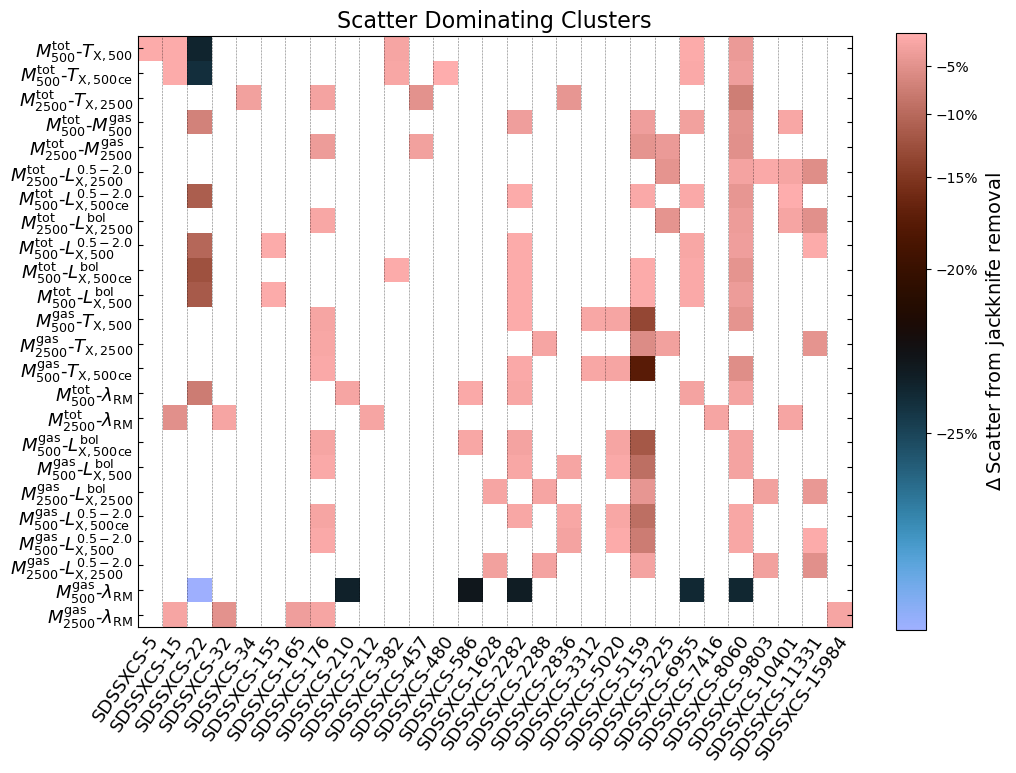

In [16]:
plt.figure(figsize=(8.5+2, 7.5))
ax = plt.gca()

# Set up the tick parameters that control which ticks and labels are shown
plt.tick_params(which='both', direction='in', top=False, right=True, bottom=False, left=True, labeltop=False)

# Set up a normalization for the image, to best communicate the percentage changes in scatter caused by each
#  cluster (there is a fair amount of dynamic range in the % changes, so we might use a stretch)
# norm = ImageNormalize(sc_ch_arr, MinMaxInterval(), stretch=LogStretch())
norm = ImageNormalize(sc_ch_arr, MinMaxInterval(), stretch=AsinhStretch())

# Plot the scatter change array - this time with normalisation
plt.imshow(sc_ch_arr, cmap='berlin', alpha=1, norm=norm)

x_tick_vals = [v+0.5 for v in range(0, len(sc_dom_for_any))]
for x_tv in x_tick_vals:
    plt.axvline(x_tv, color='black', linestyle='dotted', lw=0.4)
    
ax.set_xticks(x_tick_vals)
ax.set_xticklabels(sc_dom_for_any, fontsize=13)
for label in ax.get_xticklabels(which='both'):
    label.set(y=label.get_position()[1], rotation=55, horizontalalignment='right')

all_relation_names = [LATEX_REL_NAMES[n] if LATEX_REL_NAMES[n] != '' else n 
                      for n in list(sc_dom_names.keys())]
y_tick_vals = [v for v in range(0, len(all_relation_names))]

ax.set_yticks(y_tick_vals)
ax.set_yticklabels(all_relation_names, fontsize=13)

plt.title("Scatter Dominating Clusters", fontsize=16)

# Setting up the colorbar
cbar = plt.colorbar()
# Altering the colorbar tick labels to have percentage symbols
cbar.ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
# And adding an axis label
cbar.ax.set_ylabel(r'$\Delta\:$Scatter from jackknife removal', fontsize=14)

plt.tight_layout()
plt.savefig(rel_fig_path + "scatter_dom_cluster_grid-scatter_perc_change.pdf")
plt.show()